In [37]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from imblearn.over_sampling import RandomOverSampler
from sklearn.neural_network import MLPRegressor
from sklearn.model_selection import cross_val_score
from sklearn.metrics import mean_absolute_error, mean_squared_error
from collections import Counter
from sklearn.metrics import f1_score, recall_score, roc_auc_score, auc, precision_recall_curve

from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV


In [38]:
df = pd.read_csv("Datos_regresion.csv") # read in data downloaded to the local directory
df.head()

,Edad,Diag.Ing1,Diag.Ing2,Diag.Egr1,Diag.Egr2,APACHE,TiempoVAM,Fallece
0,35,1,0,1,0,10,2,0
1,87,2,0,2,0,16,2,0
2,70,4,0,4,0,11,2,0
3,24,13,0,13,5,11,2,0
4,24,3,0,3,0,17,3,0


In [39]:
# # Se crea un nuevo dataset con los datos de forma tal que puedan ser procesados por el algoritmo
# df_new = df[["Edad", "APACHE", "TiempoVAM"]]
# lista = ["Diag.Ing1", "Diag.Ing2", "Diag.Egr1", "Diag.Egr2"]
# for i in lista:
#     new = pd.get_dummies(df[i], prefix=i)
#     df_new = pd.concat([df_new , new], axis = 1)
# df_new = pd.concat([df_new , df.Fallece], axis =1)
# df = df_new
# df.head()

In [40]:
# df = df.drop('Diag.Egr1', axis=1)
# df = df.drop('Diag.Egr2', axis=1)

In [41]:
# total=cantidad_instancias = df.shape[0]
# 
# conteo1 = (df['Diag.Ing1'] == df['Diag.Egr1']).sum()
# diferentes1 = total - conteo1
# print("ing 1 vs egr 1")
# print(f"iguales: {conteo1}, diferentes: {diferentes1} ")
# print()
# 
# 
# conteo2 = (df['Diag.Ing2'] == df['Diag.Egr2']).sum()
# diferentes2 = total - conteo2
# print("ing 2 vs egr 2")
# print(f"iguales: {conteo2}, diferentes: {diferentes2} ")



In [42]:
# Tomamos un dato para predecir su probabilidad de morir
x_pred_f = df.loc[df.Fallece == 1]
x_pred_f = x_pred_f[1:2]
x_pred_f = x_pred_f.drop("Fallece", axis =1)

In [43]:
print(x_pred_f)

    Edad  Diag.Ing1  Diag.Ing2  Diag.Egr1  Diag.Egr2  APACHE  TiempoVAM
13    50          2          0         10         16      24          9


In [44]:
# Tomamos un dato para predecir su probabilidad de vivir
x_pred_v = df.loc[df.Fallece == 0]
x_pred_v = x_pred_v[:1]
x_pred_v = x_pred_v.drop("Fallece", axis =1)

In [45]:
print(df.shape)
print(pd.value_counts(df['Fallece'], sort = True))

(208, 8)
Fallece
0    176
1     32
Name: count, dtype: int64


C:\Users\anportal\AppData\Local\Temp\ipykernel_11968\1983737910.py:2: FutureWarning: pandas.value_counts is deprecated and will be removed in a future version. Use pd.Series(obj).value_counts() instead.
  print(pd.value_counts(df['Fallece'], sort = True))


C:\Users\anportal\AppData\Local\Temp\ipykernel_11968\545876988.py:1: FutureWarning: pandas.value_counts is deprecated and will be removed in a future version. Use pd.Series(obj).value_counts() instead.
  count_classes = pd.value_counts(df['Fallece'], sort = True)


Text(0, 0.5, 'Number of Observations')

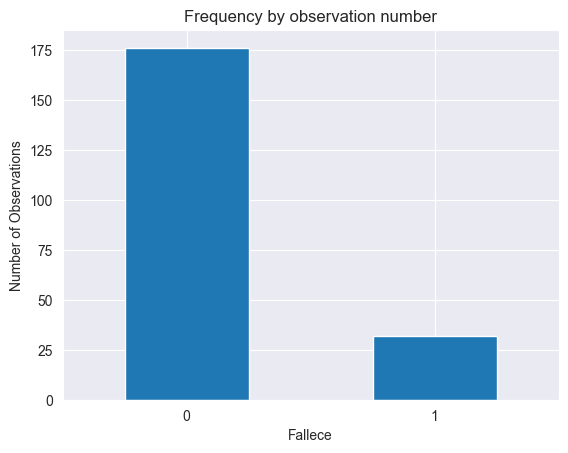

In [46]:
count_classes = pd.value_counts(df['Fallece'], sort = True)
count_classes.plot(kind = 'bar', rot=0)
plt.xticks(range(2))
plt.title("Frequency by observation number")
plt.xlabel("Fallece")
plt.ylabel("Number of Observations")

In [47]:
#definimos nuestras etiquetas y features
y = df['Fallece']
X = df.drop('Fallece', axis=1)

# Random Over Sampling

In [48]:
# # Se realiza el OVerSampling
# os =  RandomOverSampler(random_state=42)
# X_train_res, y_train_res = os.fit_resample(X, y)
# print ("Distribution before resampling {}".format(Counter(y)))
# print ("Distribution labels after resampling {}".format(Counter(y_train_res)))

# Set split

In [49]:
# Dividir los datos en conjunto de entrenamiento + validación y conjunto de prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.8, random_state=42)

# # Dividir el conjunto de entrenamiento + validación en conjunto de entrenamiento y conjunto de validación
# X_test, X_val, y_test, y_val = train_test_split(X_test_val, y_test_val, test_size=0.5, random_state=42)

In [50]:
print("Tamaño del conjunto de entrenamiento:", len(X_train))
# print("Tamaño del conjunto de validación:", len(X_val))
print("Tamaño del conjunto de prueba:", len(X_test))

Tamaño del conjunto de entrenamiento: 166
Tamaño del conjunto de prueba: 42


# KNN

In [51]:

# Configurar la búsqueda en cuadrícula
knn =  KNeighborsClassifier()
knn.fit(X_train, y_train)


# Realizar predicciones en el conjunto de prueba
y_pred = knn.predict(X_test)

In [52]:
targets=[1,0]

recall = recall_score(y_test, y_pred, labels=targets, average=None)
print("Recall Score:", recall)

f1 = f1_score(y_test, y_pred, labels=targets, average=None)
print("F1 Score:", f1)

# Calcular AUC-ROC
auc_roc = roc_auc_score(y_test, y_pred, average=None)
print("AUC-ROC:", auc_roc)

# precision, recall, _ = precision_recall_curve(y_test, y_scores)
# auc_pr = auc(recall, precision)
# print("AUC-PR:", auc_pr)

Recall Score: [0.25       0.97368421]
F1 Score: [0.33333333 0.94871795]
AUC-ROC: 0.6118421052631579


# Logistic Regression

In [53]:

# Configurar la búsqueda en cuadrícula
lr = LogisticRegression(random_state=42)
lr.fit(X_train, y_train)

# Realizar predicciones en el conjunto de prueba
y_pred = lr.predict(X_test)

In [54]:
targets=[1,0]

recall = recall_score(y_test, y_pred, labels=targets, average=None)
print("Recall Score:", recall)

f1 = f1_score(y_test, y_pred, labels=targets, average=None)
print("F1 Score:", f1)

# Calcular AUC-ROC
auc_roc = roc_auc_score(y_test, y_pred, average=None)
print("AUC-ROC:", auc_roc)



Recall Score: [0. 1.]
F1 Score: [0.   0.95]
AUC-ROC: 0.5


# MLP

In [55]:
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, balanced_accuracy_score




# Crear el objeto GridSearchCV con balanced_accuracy como métrica
mlp = MLPClassifier(random_state=42)
mlp.fit(X_train, y_train)


# Predecir en el conjunto de prueba con el modelo ajustado
y_pred = mlp.predict(X_test)


C:\Users\anportal\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


In [56]:
targets=[1,0]

recall = recall_score(y_test, y_pred, labels=targets, average=None)
print("Recall Score:", recall)

f1 = f1_score(y_test, y_pred, labels=targets, average=None)
print("F1 Score:", f1)

# Calcular AUC-ROC
auc_roc = roc_auc_score(y_test, y_pred, average=None)
print("AUC-ROC:", auc_roc)

# precision, recall, _ = precision_recall_curve(y_test, y_scores)
# auc_pr = auc(recall, precision)
# print("AUC-PR:", auc_pr)

Recall Score: [0.         0.94736842]
F1 Score: [0.         0.92307692]
AUC-ROC: 0.4736842105263158


# LIME

In [57]:
# x_pred_f = y_test.loc[df.Fallece == 1]
# x_pred_f = x_pred_f[1:2]
# x_pred_f = x_pred_f.drop("Fallece", axis =1)

In [58]:
# # Obtener la primera instancia de X_test
# prediccion = best_mlp_model.predict(X_test[:1])
# 
# print(prediccion)
# 
# print(y_test[:1])

In [59]:
# from interpret import set_visualize_provider
# from interpret.provider import InlineProvider
# set_visualize_provider(InlineProvider())
# from interpret import show
# from interpret.blackbox import LimeTabular

In [60]:
# lime = LimeTabular(best_mlp_model, X_train)
# 
# 
# lime = LimeTabular(best_mlp_model, X_train)
# 
# show(lime.explain_local(X_test[:10], y_test[:10]), 0)